# Paraná Rural Access Equity — End-to-End Narrative

**Question:** Which of Paraná's 399 municípios are underserved by rural health, education, and agricultural extension services relative to their rural population?

**Method:** Enhanced 2-Step Floating Catchment Area (Luo & Qi, 2009) over IBGE + CNES + INEP + IDR-PR data. Composite of equal-weight percentile ranks. Quintile classification.

**Everything below reuses the `src/` package.** This notebook exists to narrate the pipeline for a reader. To reproduce headlessly, use `make all` or `python -m src.compute_scores`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repo root importable regardless of where the notebook is opened.
REPO = Path.cwd().resolve()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data_ibge import load_muni_with_population
from src.data_cnes import load_primary_care_pr
from src.data_inep import load_rural_schools_pr
from src.data_ater import load_ater_stations
from src.access import score_service
from src.compute_scores import build_scores, percentile_rank, classify_quintiles
from src.render_outputs import render_static, render_per_service_grid, render_interactive

## 1. Base geography + rural population

Malha municipal 2022 (399 features) joined against SIDRA table 9923 (Censo 2022 populacao por situacao do domicilio). Both fetched from IBGE, cached in `data/raw/`.

In [2]:
munis = load_muni_with_population()
print(f"municipios: {len(munis)}, rural pop total: {munis['pop_rural'].sum():,.0f}")
munis[['CD_MUN', 'NM_MUN', 'pop_total', 'pop_urbana', 'pop_rural', 'pct_rural']].head()

2026-07-01 11:36:30,083 INFO parana_rural_access: cache hit: PR_Municipios_2022.zip


2026-07-01 11:36:32,426 INFO parana_rural_access: cache hit: sidra_9923_pr.parquet


2026-07-01 11:36:34,020 INFO parana_rural_access: saved 399 municipios -> pr_muni_pop2022.gpkg


municipios: 399, rural pop total: 1,264,533


,CD_MUN,NM_MUN,pop_total,pop_urbana,pop_rural,pct_rural
0,4100103,Abatiá,7241.0,5472.0,1769.0,0.244303
1,4100202,Adrianópolis,6256.0,2072.0,4184.0,0.668798
2,4100301,Agudos do Sul,10233.0,4234.0,5999.0,0.586241
3,4100400,Almirante Tamandaré,119825.0,114555.0,5270.0,0.043981
4,4100459,Altamira do Paraná,3590.0,1944.0,1646.0,0.458496


## 2. Supply layers — CNES primary care, INEP rural schools, IDR-PR extension

In [3]:
cnes = load_primary_care_pr()
inep = load_rural_schools_pr()
ater = load_ater_stations()
print(f"CNES primary care: {len(cnes):5d}")
print(f"INEP rural schools: {len(inep):5d}")
print(f"IDR-PR ATER stations: {len(ater):5d}")

2026-07-01 11:36:34,050 INFO parana_rural_access: cache hit: cnes_pr_primary_202605.gpkg


2026-07-01 11:36:34,081 INFO parana_rural_access: cache hit: inep_pr_rural_2024.gpkg


2026-07-01 11:36:34,093 INFO parana_rural_access: cache hit: ater_pr_stations.gpkg


CNES primary care:  3075
INEP rural schools:  1187
IDR-PR ATER stations:   414


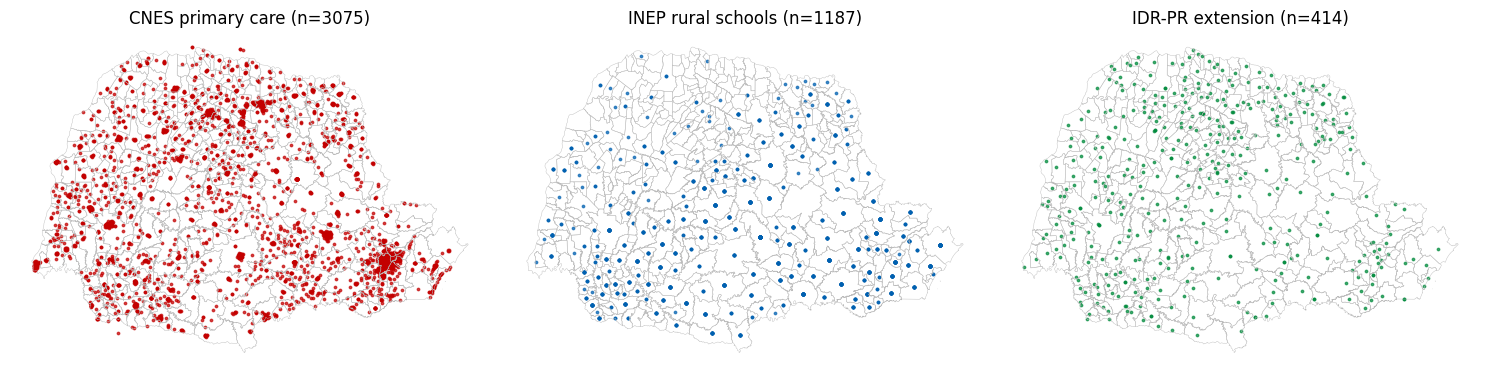

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, layer, title, color in zip(
    axes,
    (cnes, inep, ater),
    ('CNES primary care', 'INEP rural schools', 'IDR-PR extension'),
    ('#c30000', '#0060b0', '#008a3c'),
):
    munis.boundary.plot(ax=ax, color='#bbbbbb', linewidth=0.3)
    layer.plot(ax=ax, color=color, markersize=3, alpha=0.7)
    ax.set_title(f"{title} (n={len(layer)})")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. E2SFCA scores per service

Uses `src.access.score_service` under the hood. Gaussian decay β = 30 km, catchment cutoff d₀ = 50 km. See `docs/METHODOLOGY.md` for the math and the citations.

In [5]:
munis['health_e2sfca'] = score_service(munis, cnes, service_name='health')
munis['education_e2sfca'] = score_service(munis, inep, service_name='education')
munis['extension_e2sfca'] = score_service(munis, ater, service_name='extension')

for col in ('health_e2sfca', 'education_e2sfca', 'extension_e2sfca'):
    munis[f'{col.split("_")[0]}_pct'] = percentile_rank(munis[col])

munis[['NM_MUN', 'pop_rural', 'health_pct', 'education_pct', 'extension_pct']].sort_values(
    ['health_pct', 'education_pct', 'extension_pct']
).head(10)

2026-07-01 11:36:36,200 INFO parana_rural_access: health E2SFCA: 399 demand pts, 3075 supply pts, beta=30.0 km, d0=50.0 km


2026-07-01 11:36:36,292 INFO parana_rural_access: education E2SFCA: 399 demand pts, 1187 supply pts, beta=30.0 km, d0=50.0 km


2026-07-01 11:36:36,363 INFO parana_rural_access: extension E2SFCA: 399 demand pts, 414 supply pts, beta=30.0 km, d0=50.0 km


,NM_MUN,pop_rural,health_pct,education_pct,extension_pct
381,Tunas do Paraná,1885.0,0.250627,86.967419,16.541353
1,Adrianópolis,4184.0,0.501253,80.952381,27.067669
183,Laranjal,3266.0,0.751880,59.398496,28.571429
96,Diamante do Sul,1755.0,1.002506,65.914787,30.075188
248,Palmital,5617.0,1.253133,58.395990,22.556391
263,Piên,7587.0,1.503759,75.689223,1.253133
2,Agudos do Sul,5999.0,1.754386,82.456140,4.010025
212,Marquinho,3026.0,2.005013,65.664160,21.052632
377,Tijucas do Sul,8372.0,2.255639,93.233083,9.273183
15,Antônio Olinto,5807.0,2.506266,77.944862,6.265664


## 4. Composite + quintiles

Equal-weight average of the three per-service percentile ranks, re-ranked to obtain the composite percentile. Q1 = worst 20%.

In [6]:
munis['composite_raw'] = (
    (munis['health_pct'] + munis['education_pct'] + munis['extension_pct']) / 3
)
munis['composite_pct'] = percentile_rank(munis['composite_raw'])
munis['is_ranked'] = munis['pop_rural'].fillna(0) >= config.MIN_RURAL_POPULATION

ranked = munis[munis['is_ranked']].copy()
ranked['quintile'] = classify_quintiles(ranked['composite_pct'])
munis['quintile'] = pd.NA
munis.loc[ranked.index, 'quintile'] = ranked['quintile']
munis['underserved'] = munis['quintile'] == 1

bottom = ranked[ranked['quintile'] == 1]
print(f"Bottom quintile: {len(bottom)} municipios housing {bottom['pop_rural'].sum():,.0f} "
      f"rural residents ({100 * bottom['pop_rural'].sum() / ranked['pop_rural'].sum():.1f}% of ranked rural pop).")

Bottom quintile: 73 municipios housing 338,499 rural residents (27.0% of ranked rural pop).


## 5. Sensitivity checks

Recompute bottom-quintile (Q1) membership under equal weights, health-heavy, education-heavy, and PC1-derived weights, and measure the overlap with the equal-weight baseline.

The honest reading for Paraná: Q1 is fairly stable when the weighting tilts toward health (91.8 percent overlap), because primary-care access and extension access co-vary here (they concentrate in the same more-developed municípios). Rural-school access is the mirror image, strongest in the center-south, so reweighting toward education moves Q1 more (56.2 percent). Under PC1 the overlap is only 45.2 percent, because the first principal component loads as a (health + extension) versus education contrast rather than a shared access axis. That tension is a finding, not a failure, and it is why we publish the per-service maps next to the composite.

In [7]:
def bottom_set(composite):
    r = composite[munis['is_ranked']].dropna()
    cutoff = r.quantile(0.20)
    return set(r[r <= cutoff].index)

h, e, x = munis['health_pct'], munis['education_pct'], munis['extension_pct']
schemes = {
    'equal weights':            (h + e + x) / 3,
    'health-heavy .5/.25/.25':  0.5 * h + 0.25 * e + 0.25 * x,
    'education-heavy .25/.5/.25': 0.25 * h + 0.5 * e + 0.25 * x,
}

# PC1 weights from the z-scored per-service columns. Use eigh and take the
# eigenvector of the LARGEST eigenvalue (last column with eigh).
svc = munis[['health_pct', 'education_pct', 'extension_pct']].dropna()
std = (svc - svc.mean()) / svc.std()
cov = np.cov(std.values.T)
eigvals, eigvecs = np.linalg.eigh(cov)
w = eigvecs[:, -1]
if w.sum() < 0:
    w = -w
w = w / w.sum()
print(f"PC1 weights (health, education, extension): {[round(float(v), 3) for v in w]}")
schemes['PC1-derived'] = pd.Series(svc.values @ w, index=svc.index).reindex(munis.index)

base = bottom_set(schemes['equal weights'])
for name, comp in schemes.items():
    s = bottom_set(comp)
    overlap = len(s & base) / max(len(base), 1)
    print(f"{name:28s} n={len(s):3d}  overlap with equal-weight: {100*overlap:5.1f}%")

PC1 weights (health, education, extension): [0.877, -0.879, 1.002]
equal weights                n= 73  overlap with equal-weight: 100.0%
health-heavy .5/.25/.25      n= 74  overlap with equal-weight:  91.8%
education-heavy .25/.5/.25   n= 73  overlap with equal-weight:  56.2%
PC1-derived                  n= 73  overlap with equal-weight:  45.2%


## 6. Persist + render

Delegates to `src.compute_scores.build_scores` (which recomputes end-to-end and writes `data/processed/pr_muni_access_scores.gpkg` + `output/headline_stats.json`) and `src.render_outputs` (which produces the PNG + interactive HTML).

In [8]:
gdf_final = build_scores()
render_static(gdf_final)
render_per_service_grid(gdf_final)
render_interactive(gdf_final)
print('outputs:')
for p in sorted(config.OUTPUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(config.OUTPUT_DIR)}  ({p.stat().st_size/1024:.1f} KB)')

2026-07-01 11:36:36,508 INFO parana_rural_access: == compute_scores ==


2026-07-01 11:36:36,509 INFO parana_rural_access: cache hit: PR_Municipios_2022.zip


2026-07-01 11:36:36,530 INFO parana_rural_access: cache hit: sidra_9923_pr.parquet


2026-07-01 11:36:36,615 INFO parana_rural_access: saved 399 municipios -> pr_muni_pop2022.gpkg


2026-07-01 11:36:36,616 INFO parana_rural_access: cache hit: cnes_pr_primary_202605.gpkg


...

2026-07-01 11:36:37,030 INFO parana_rural_access: wrote headline stats -> headline_stats.json


2026-07-01 11:36:37,485 INFO parana_rural_access: wrote choropleth_access_score.png


2026-07-01 11:36:38,600 INFO parana_rural_access: wrote figures\access_by_service.png


2026-07-01 11:36:40,067 INFO parana_rural_access: wrote interactive_map.html (3526.7 KB)


outputs:
  .gitkeep  (0.0 KB)
  bottom_quintile.csv  (13.9 KB)
  choropleth_access_score.png  (576.8 KB)
  figures\access_by_service.png  (505.9 KB)
  headline_stats.json  (1.8 KB)
  interactive_map.html  (3526.7 KB)
  muni_access_scores.csv  (74.3 KB)


## Reproducibility

Everything in this notebook is a thin wrapper over `src/`. To rerun from scratch on any machine:

```bash
make install    # venv + pip install -r requirements.txt
make all        # download + score + render
```

See `docs/METHODOLOGY.md` for the math and citations; `docs/WRITEUP_EN.md` and `docs/WRITEUP_PT.md` for the portfolio narratives; `docs/linkedin_posts.md` for the launch drafts.